In [1]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extraction_dir = 'data_unzipped'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

# Open the zip file and extract all its contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"Successfully extracted '{zip_file_path}' to '{extraction_dir}'")


Successfully extracted '/content/archive (1).zip' to 'data_unzipped'


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Classes : ['Cloudy', 'Rain', 'Shine', 'Sunrise']
Train: 845  |  Val: 168  |  Test: 112
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 194MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Frozen] Ep 01 | tr_loss=0.6482 tr_acc=0.7290 | vl_loss=0.3880 vl_acc=0.8750 | 12.0s
[Frozen] Ep 02 | tr_loss=0.3863 tr_acc=0.8781 | vl_loss=0.2889 vl_acc=0.9107 | 10.3s
[Frozen] Ep 03 | tr_loss=0.3651 tr_acc=0.8651 | vl_loss=0.2729 vl_acc=0.9107 | 9.7s
[Frozen] Ep 04 | tr_loss=0.3316 tr_acc=0.8876 | vl_loss=0.2456 vl_acc=0.9167 | 9.9s
[Frozen] Ep 05 | tr_loss=0.3238 tr_acc=0.8805 | vl_loss=0.2410 vl_acc=0.9107 | 10.7s
[Tuning] Ep 01 | tr_loss=0.3503 tr_acc=0.8710 | vl_loss=0.2303 vl_acc=0.9167 | 9.8s
[Tuning] Ep 02 | tr_loss=0.2886 tr_acc=0.8876 | vl_loss=0.2137 vl_acc=0.9226 | 9.6s
[Tuning] Ep 03 | tr_loss=0.2333 tr_acc=0.9207 | vl_loss=0.2257 vl_acc=0.9167 | 10.6s
[Tuning] Ep 04 | tr_loss=0.2015 tr_acc=0.9314 | vl_loss=0.2095 vl_acc=0.9286 | 10.4s
[Tuning] Ep 05 | tr_loss=0.2099 tr_acc=0.9314 | vl_loss=0.2012 vl_acc=0.9345 | 9.7s
Best Val Accuracy: 0.9345

Test Loss: 0.1253 | Test Accuracy: 0.9643
              precision    recall  f1-score   support

      Cloudy       0.94      0.

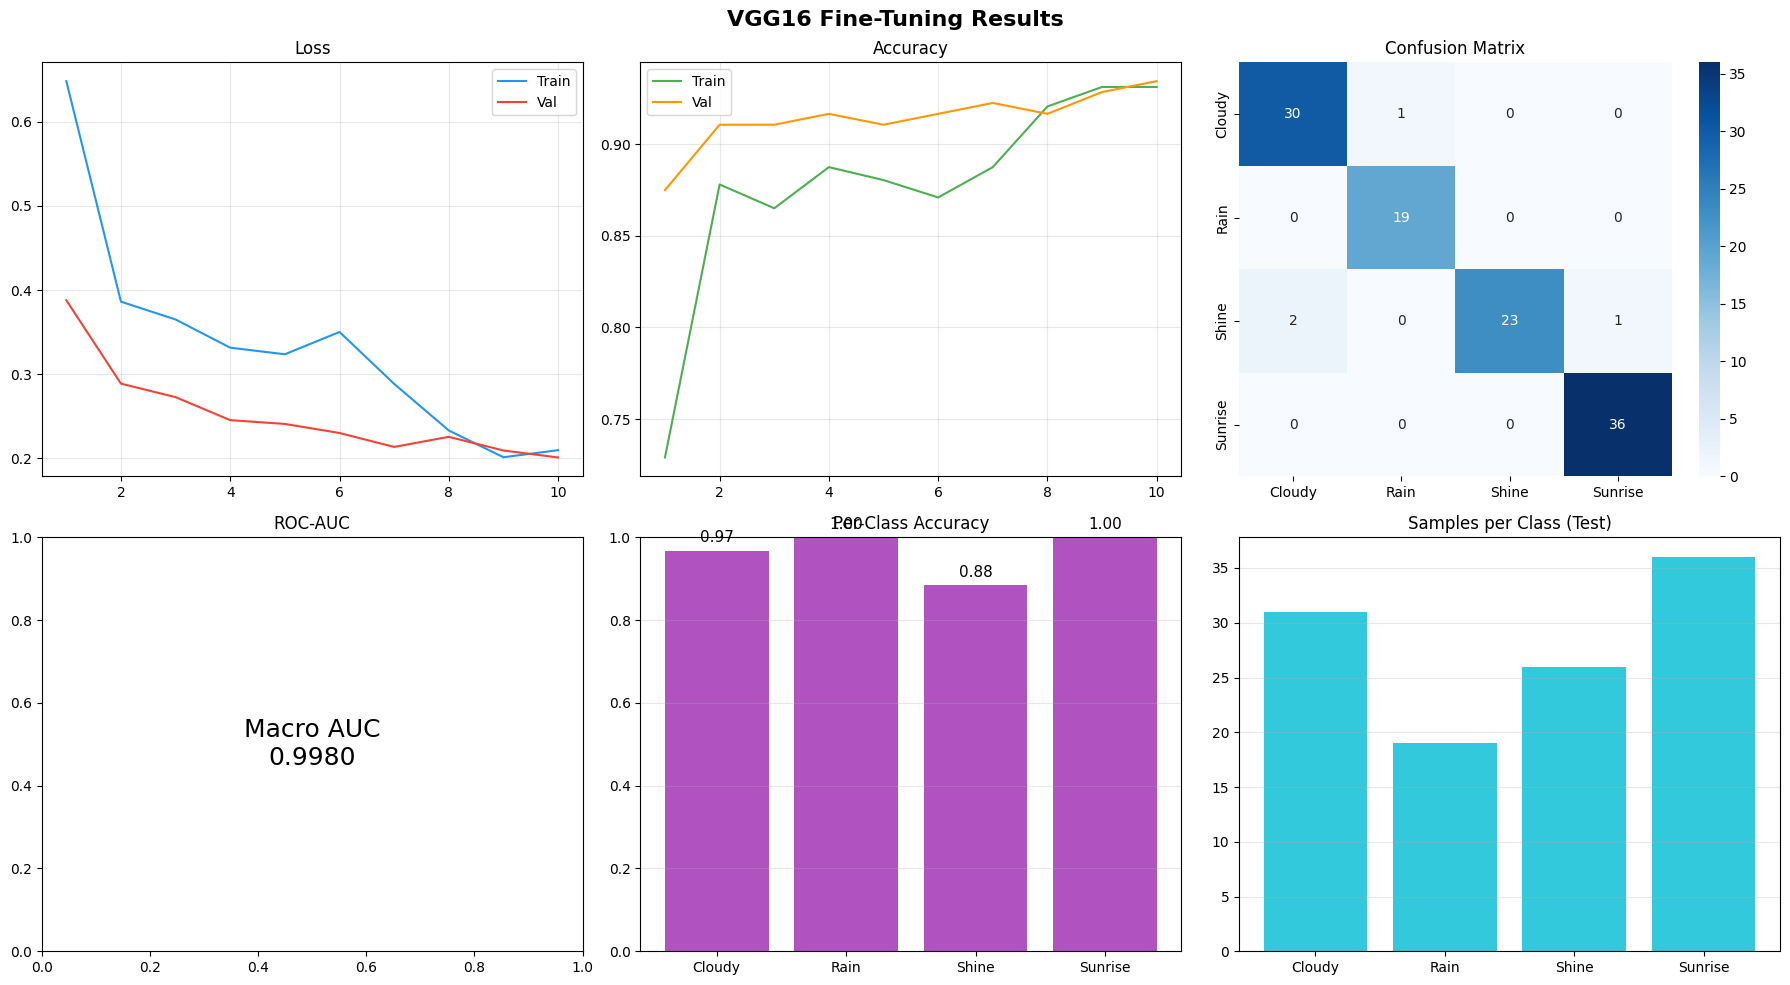

In [3]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


CONFIG = {
    "data_dir"        : data_root_dir,
    "img_size"        : 224,
    "batch_size"      : 32,
    "val_split"       : 0.15,
    "test_split"      : 0.10,
    "num_workers"     : 4,
    "epochs_frozen"   : 5,
    "epochs_unfrozen" : 5,
    "lr_head"         : 1e-3,
    "lr_backbone"     : 1e-5,
    "weight_decay"    : 1e-4,
    "patience"        : 7,
    "seed"            : 42,
    "device"          : "cuda" if torch.cuda.is_available() else "cpu",
    "save_path"       : "best_vgg16.pth",
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


def get_transforms(img_size):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size + 32, img_size + 32)),
        transforms.RandomCrop(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_tf, val_tf


def build_dataloaders(cfg):
    train_tf, val_tf = get_transforms(cfg["img_size"])
    full_dataset = datasets.ImageFolder(cfg["data_dir"], transform=train_tf)

    num_classes = len(full_dataset.classes)
    cfg["num_classes"] = num_classes

    n       = len(full_dataset)
    n_test  = int(n * cfg["test_split"])
    n_val   = int(n * cfg["val_split"])
    n_train = n - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        full_dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(cfg["seed"])
    )

    val_ds.dataset  = copy.deepcopy(full_dataset)
    test_ds.dataset = copy.deepcopy(full_dataset)
    val_ds.dataset.transform  = val_tf
    test_ds.dataset.transform = val_tf

    targets      = [full_dataset.targets[i] for i in train_ds.indices]
    class_counts = np.bincount(targets)
    class_weights = torch.tensor(
        [n_train / (num_classes * c) for c in class_counts], dtype=torch.float
    )

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                            num_workers=cfg["num_workers"], pin_memory=True),
        "val"  : DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False,
                            num_workers=cfg["num_workers"], pin_memory=True),
        "test" : DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False,
                            num_workers=cfg["num_workers"], pin_memory=True),
    }

    print(f"Classes : {full_dataset.classes}")
    print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")

    return dataloaders, full_dataset.classes, class_weights


class VGG16FineTuner(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = "IMAGENET1K_V1" if pretrained else None
        self.backbone = models.vgg16(weights=weights)

        feat_dim = self.backbone.classifier[6].in_features
        self.backbone.classifier[6] = nn.Identity()

        self.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

        self._freeze_backbone()

    def _freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_last_n_layers(self, n):
        children = list(self.backbone.features.children())
        for child in children[:-n]:
            for param in child.parameters():
                param.requires_grad = False
        for child in children[-n:]:
            for param in child.parameters():
                param.requires_grad = True
        for param in self.backbone.classifier.parameters():
            param.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience  = patience
        self.delta     = delta
        self.best_loss = np.inf
        self.counter   = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


def build_optimizer(model, cfg, phase):
    if phase == "frozen":
        return optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg["lr_head"], weight_decay=cfg["weight_decay"]
        )
    return optim.Adam([
        {"params": model.backbone.parameters(), "lr": cfg["lr_backbone"]},
        {"params": model.head.parameters(),     "lr": cfg["lr_head"]},
    ], weight_decay=cfg["weight_decay"])


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        probs   = torch.softmax(outputs, dim=1)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += imgs.size(0)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (running_loss / total, correct / total,
            np.array(all_probs), np.array(all_labels))


def train(model, dataloaders, cfg):
    device    = cfg["device"]
    model     = model.to(device)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    es        = EarlyStopping(patience=cfg["patience"])
    best_acc  = 0.0
    criterion = nn.CrossEntropyLoss(weight=dataloaders["class_weights"].to(device))

    optimizer = build_optimizer(model, cfg, "frozen")
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs_frozen"])

    for epoch in range(1, cfg["epochs_frozen"] + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(model, dataloaders["val"], criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"[Frozen] Ep {epoch:02d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} "
              f"| vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | {time.time()-t0:.1f}s")

        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), cfg["save_path"])

    model.unfreeze_last_n_layers(4)
    optimizer = build_optimizer(model, cfg, "unfrozen")
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs_unfrozen"], eta_min=1e-7)

    for epoch in range(1, cfg["epochs_unfrozen"] + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(model, dataloaders["val"], criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"[Tuning] Ep {epoch:02d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} "
              f"| vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | {time.time()-t0:.1f}s")

        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), cfg["save_path"])

        if es(vl_loss):
            print(f"Early stopping at epoch {epoch}")
            break

    print(f"Best Val Accuracy: {best_acc:.4f}")
    return history


def evaluate_test(model, dataloaders, cfg, class_names):
    device = cfg["device"]
    model.load_state_dict(torch.load(cfg["save_path"], map_location=device))
    model  = model.to(device)
    criterion = nn.CrossEntropyLoss()

    loss, acc, probs, labels = evaluate(model, dataloaders["test"], criterion, device)
    preds = probs.argmax(axis=1)

    print(f"\nTest Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")
    print(classification_report(labels, preds, target_names=class_names))

    return probs, labels, preds


def plot_results(history, probs, labels, preds, class_names):
    num_classes = len(class_names)
    fig, axes   = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("VGG16 Fine-Tuning Results", fontsize=16, fontweight="bold")

    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0, 0].plot(epochs, history["train_loss"], label="Train", color="#2196F3")
    axes[0, 0].plot(epochs, history["val_loss"],   label="Val",   color="#F44336")
    axes[0, 0].set_title("Loss"); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, history["train_acc"], label="Train", color="#4CAF50")
    axes[0, 1].plot(epochs, history["val_acc"],   label="Val",   color="#FF9800")
    axes[0, 1].set_title("Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0, 2])
    axes[0, 2].set_title("Confusion Matrix")

    if num_classes == 2:
        fpr, tpr, _ = roc_curve(labels, probs[:, 1])
        auc_val      = roc_auc_score(labels, probs[:, 1])
        axes[1, 0].plot(fpr, tpr, color="#E91E63", linewidth=2, label=f"AUC={auc_val:.4f}")
        axes[1, 0].plot([0, 1], [0, 1], "k--")
        axes[1, 0].set_title("ROC Curve"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
    else:
        auc_val = roc_auc_score(
            np.eye(num_classes)[labels.astype(int)], probs,
            multi_class="ovr", average="macro"
        )
        axes[1, 0].text(0.5, 0.5, f"Macro AUC\n{auc_val:.4f}",
                        ha="center", va="center", fontsize=18, transform=axes[1, 0].transAxes)
        axes[1, 0].set_title("ROC-AUC")

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    axes[1, 1].bar(class_names, per_class_acc, color="#9C27B0", alpha=0.8)
    axes[1, 1].set_title("Per-Class Accuracy"); axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(alpha=0.3, axis="y")
    for i, v in enumerate(per_class_acc):
        axes[1, 1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=11)

    axes[1, 2].bar(class_names, cm.sum(axis=1), color="#00BCD4", alpha=0.8)
    axes[1, 2].set_title("Samples per Class (Test)"); axes[1, 2].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("vgg16_results.png", dpi=150, bbox_inches="tight")
    print("Saved → vgg16_results.png")
    plt.show()


def main():
    cfg = CONFIG.copy()

    if not os.path.isdir(cfg["data_dir"]):
        print(f"[ERROR] Data folder '{cfg['data_dir']}' not found.")
        print("Organize your data as:")
        print("  data/")
        print("  ├── class_1/")
        print("  ├── class_2/")
        print("  └── class_n/")
        return

    dataloaders, class_names, class_weights = build_dataloaders(cfg)
    dataloaders["class_weights"] = class_weights

    model = VGG16FineTuner(num_classes=cfg["num_classes"], pretrained=True)

    history = train(model, dataloaders, cfg)
    probs, labels, preds = evaluate_test(model, dataloaders, cfg, class_names)
    plot_results(history, probs, labels, preds, class_names)


if __name__ == "__main__":
    main()